In [1]:
import pandas as pd

df = pd.read_csv('desafio_nps_fase_1.csv')

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [2]:
import pandas as pd

# separando em grupos de nps
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['categoria_nps'] = df['nps_score'].apply(classificar_nps)

# vendo a proporcao dos grupos
print("=== Porcentagem de Clientes ===")
print(df['categoria_nps'].value_counts(normalize=True) * 100)

# comparando as medias operacionais
print("\n=== Medias das Operacoes por Grupo ===")
colunas = ['delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'delivery_time_days', 'freight_value']
print(df.groupby('categoria_nps')[colunas].mean().round(2))

# vendo o que mais afeta a nota
print("\n=== Correlacao com a nota NPS ===")
print(df.corr(numeric_only=True)['nps_score'].sort_values().round(2))

=== Porcentagem de Clientes ===
categoria_nps
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64

=== Medias das Operacoes por Grupo ===
               delivery_delay_days  customer_service_contacts  \
categoria_nps                                                   
Detrator                      2.53                       1.69   
Neutro                        1.40                       1.13   
Promotor                      0.76                       0.78   

               resolution_time_days  delivery_time_days  freight_value  
categoria_nps                                                           
Detrator                       5.79                8.00          38.40  
Neutro                         4.83                8.12          37.91  
Promotor                       4.10                8.04          37.21  

=== Correlacao com a nota NPS ===
delivery_delay_days         -0.60
complaints_count            -0.50
customer_service_contacts   -0.35

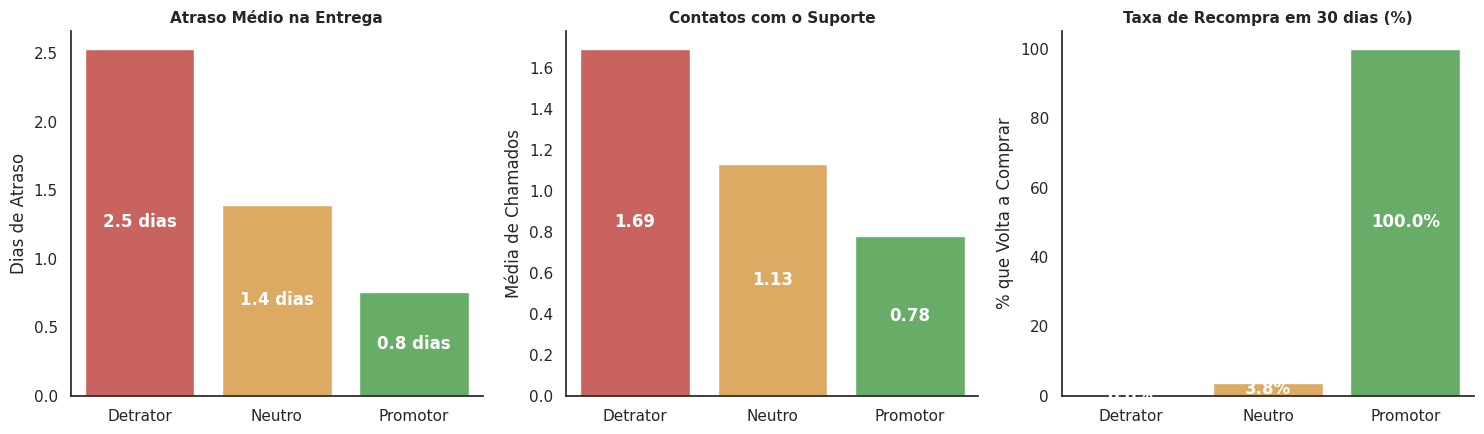

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white')
ordem = ['Detrator', 'Neutro', 'Promotor']
# definindo a cor exata de cada grupo
cores = {'Detrator': '#d9534f', 'Neutro': '#f0ad4e', 'Promotor': '#5cb85c'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# atraso medio
ax1 = sns.barplot(
    data=df,
    x='categoria_nps',
    y='delivery_delay_days',
    order=ordem,
    hue='categoria_nps',
    palette=cores,
    legend=False,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title('Atraso Médio na Entrega', fontweight='bold', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Dias de Atraso')
for p in ax1.patches:
    ax1.annotate(
        f'{p.get_height():.1f} dias',
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
    )

# suporte
ax2 = sns.barplot(
    data=df,
    x='categoria_nps',
    y='customer_service_contacts',
    order=ordem,
    hue='categoria_nps',
    palette=cores,
    legend=False,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title('Contatos com o Suporte', fontweight='bold', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Média de Chamados')
for p in ax2.patches:
    ax2.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
    )

# taxa de recompra
recompra = (
    df.groupby('categoria_nps')['repeat_purchase_30d'].mean() * 100
).reindex(ordem)
ax3 = sns.barplot(
    x=recompra.index,
    y=recompra.values,
    hue=recompra.index,
    palette=cores,
    legend=False,
    ax=axes[2],
)
axes[2].set_title(
    'Taxa de Recompra em 30 dias (%)', fontweight='bold', fontsize=11
)
axes[2].set_xlabel('')
axes[2].set_ylabel('% que Volta a Comprar')
for p in ax3.patches:
    ax3.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
    )

sns.despine()
plt.tight_layout()
plt.show()

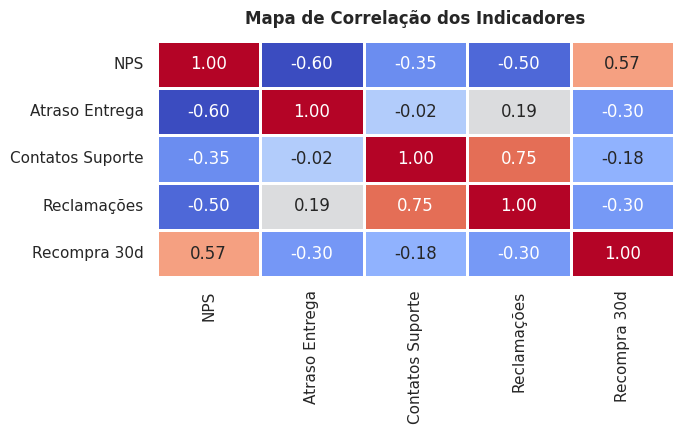

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5))

colunas = [
    'nps_score',
    'delivery_delay_days',
    'customer_service_contacts',
    'complaints_count',
    'repeat_purchase_30d',
]
matriz = df[colunas].corr()

matriz.columns = [
    'NPS',
    'Atraso Entrega',
    'Contatos Suporte',
    'Reclamações',
    'Recompra 30d',
]
matriz.index = matriz.columns

sns.heatmap(
    matriz, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, cbar=False
)
plt.title('Mapa de Correlação dos Indicadores', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()